## Data Curation
This is a notebook to give a glimpse into the information available in the .json test field files. I will show how to access the different attributes and describe the revelance they have to this paper

## Load at Data

In [1]:
import pandas as pd
import json

In [2]:
with open("testfield.json", "r") as f:
    field_info = json.load(f)

In [3]:
field_info

{'fieldId': 2382369,
 'name': 'A1',
 'description': 'A_G181CW',
 'machineName': 'NA11',
 'machineType': 'Agility',
 'type': 'Vmat',
 'mqType': 'Vmat',
 'isocentre': {'x': 0.18, 'y': -3.4, 'z': -102.6},
 'beamMeterset': 471.3,
 'mqControlPoints': [{'point': 0,
   'mlcLeaves': 80,
   'cumulativeMetersetWeight': 0,
   'leafSetA': [2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.08,
    2.86,
    -0.18,
    -0.76,
    -1.01,
    -0.96,
    -0.2,
    0.1,
    -1.53,
    -1.75,
    -1.86,
    -2.12,
    -2.18,
    -1.69,
    -2.18,
    -1.63,
    -1.15,
    -0.42,
    -0.25,
    0.01,
    0.01,
    0.01,
    -0.13,
    -0.13,
    -0.13,
    -0.13,
    -0.13,
    -0.13,
    -0.13,
    -0.13,
    -0.13,
    -0.13,
    -0.13,
    -0.13,
    -0.1

In [4]:
field_info.keys()

dict_keys(['fieldId', 'name', 'description', 'machineName', 'machineType', 'type', 'mqType', 'isocentre', 'beamMeterset', 'mqControlPoints', 'beamEnergy', 'isFff', 'bolusStatus', 'hasBolus'])

In [5]:
field_info["fieldId"]

# how many unique fields are here?
# does the fieldId has any underlying meaning?

2382369

No meaning, irrelevant

In [6]:
field_info["name"]

# what does the name correspond to?

'A1'

In [6]:
field_info["description"]

# document to decipher the description?

'A_G181CW'

In [7]:
field_info["machineName"]

# how many different machine names can there be?

'NA11'

In [8]:
field_info["machineType"]

# how many different machine types are there?
# what are the differences between machine types?

'Agility'

Tells you how the leaves are configured, how wide the leaves are

Two other types
    - varian (company name): different leaf config, small leaves in the centre 5mm, wider leaves off center. 
    - unimportant

gantry angle, in the physical space, where the gantry angle is located when it begins. 0 ceiling, 180 from below. 
collimator angle - angle from the principal axis on which the collimators are rotated on.

fieldX - agility linax: distance between the blue zones, the length of the field in which radiation makes it through to the patient. 

In [9]:
field_info["beamEnergy"]

# does the beam energy change throughout the treatment or does it stay constant for the patient?
# what unit is used to defined beam energy and what is the range of beam energy for each machine

6

In [10]:
field_info['beamMeterset']

# units?
# what does it mean?

471.3

In [11]:
field_info['hasBolus']

False

In [12]:
field_info["bolusStatus"]

# is the empty string mean redundant with false bolus?

''

In [13]:
field_info["isFff"]

# fff - flatting filter free: higher average dose rate with higher dose per pulse and inhomogeneous dose distribution with reduced peripheral dose

False

In [14]:
field_info["isocentre"]

# is this the centre of the target (tumor/test object) positioned on the machine?

{'x': 0.18, 'y': -3.4, 'z': -102.6}

In [15]:
field_info["mqControlPoints"]
len(field_info['mqControlPoints'])

# will each field have 180 control points
# what is mq?

180

leafset measurements are measured in cm.

In [16]:
field_info["mqType"]

# What are the types and how do they differ?

'Vmat'

In [17]:
field_info["isocentre"]

{'x': 0.18, 'y': -3.4, 'z': -102.6}

## Radial Plotting

In [7]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import numpy as np

In [8]:
control_points = field_info["mqControlPoints"]

segments = range(180)

In [9]:
def degrees_to_radians(degrees_list): # written by chatgpt
    import math
    radians_list = [math.radians(angle) for angle in degrees_list]
    return radians_list

def plot_radial_leaf_progression(leaf_number, control_points):
    import numpy as np 
    import matplotlib.pyplot as plt

    gantrys = []
    leafA_values = []
    leafB_values = []

    for i in control_points:
        gantrys.append(i["gantryAngle"])
        leafA_values.append(i["leafSetA"][leaf_number])
        leafB_values.append(i["leafSetB"][leaf_number])

    gantrys = degrees_to_radians(gantrys)

    offset = np.pi / 2

    fig, ax = plt.subplots(figsize = (20,10), subplot_kw={"projection":"polar"})

    ax.set_theta_offset(offset)

    ax.set_ylim(-10, 10)

    ax.set_frame_on(False)

    ax.plot(gantrys, pd.Series(leafA_values), drawstyle = "steps", mouseover = True)#, width = width, fill = False, edgecolor = "blue")
    ax.plot(gantrys, -pd.Series(leafB_values), drawstyle = "steps", mouseover = True)#, width = width, fill = False, edgecolor = "red")

    plt.show()

    return



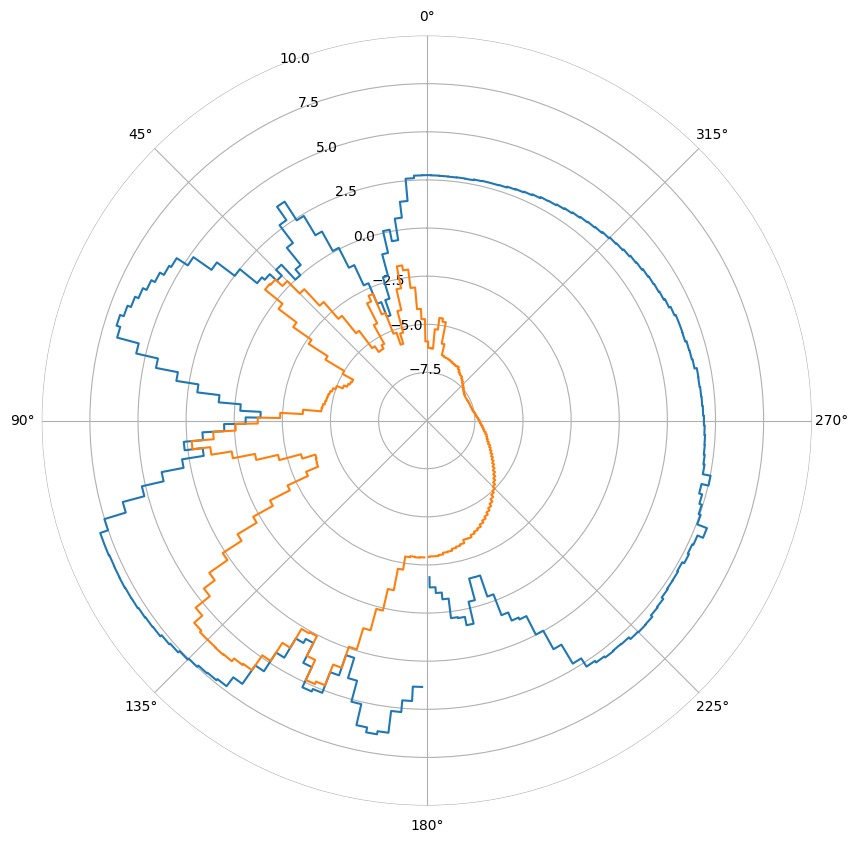

In [10]:
plot_radial_leaf_progression(40, field_info["mqControlPoints"])